In [1]:
import numpy as np 
import pandas as pd 

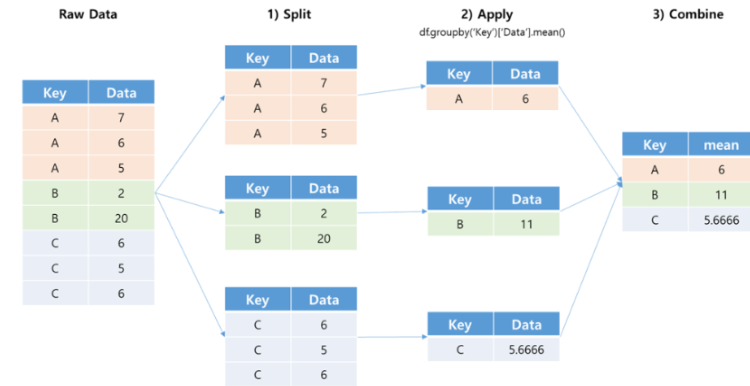

In [102]:
# group by 
# 1. What is the average GPA for each major?
students_df.groupby('Major')['GPA'].mean()

Major
Biology             2.800
Computer Science    2.000
Math                3.275
Name: GPA, dtype: float64

In [103]:
students_df.groupby('Major')[['GPA']].mean()

,GPA
Major,
Biology,2.800
Computer Science,2.000
Math,3.275


In [105]:
# What is the median, min, max, mean age of students in each major?
students_df.groupby('Major')[['Age']].agg(['min','max','mean','median'])
# in this way we can calculate multiple agg function result 


Age                   
                   min   max  mean median
Major                                    
Biology           19.0  23.0  21.0   21.0
Computer Science  21.0  21.0  21.0   21.0
Math              20.0  22.0  21.0   21.0

In [106]:
# What is the median, min, max, mean Average of students in each Lecture?
students_df.groupby('Lecture')[['Average']].agg(['min','max','mean','median'])

Average                    
                     min   max   mean median
Lecture                                     
Algorithms          30.5  42.0  36.25  36.25
Calculus            46.0  46.0  46.00  46.00
Electromagnetism    70.5  70.5  70.50  70.50
Genetics            84.5  84.5  84.50  84.50
Linear Algebra      75.5  75.5  75.50  75.50
Microbiology        38.5  89.5  64.00  64.00
Probability         82.5  82.5  82.50  82.50

In [107]:
# What is the median, min, max, mean age of students in each major for each lecture? 
students_df.groupby(['Major','Lecture'])[['Average']].agg(['min','max','mean','median'])

Average                    
                                      min   max   mean median
Major            Lecture                                     
Biology          Electromagnetism    70.5  70.5  70.50  70.50
                 Microbiology        38.5  89.5  64.00  64.00
Computer Science Algorithms          30.5  42.0  36.25  36.25
Math             Calculus            46.0  46.0  46.00  46.00
                 Genetics            84.5  84.5  84.50  84.50
                 Linear Algebra      75.5  75.5  75.50  75.50
                 Probability         82.5  82.5  82.50  82.50

In [110]:
# Find the corr between the columns GPA and Average
students_df[['GPA','Average']].corr()
# High positive correlation between gpa and average 

,GPA,Average
GPA,1.000000,0.954053
Average,0.954053,1.000000


In [111]:
# add a new column showing the students situation if passed or failed according to the average >= 60
students_df['situation'] = students_df['Average'].apply(lambda x: 'Passed' if x >= 60 else 'Failed' )

In [112]:
students_df

,Name,Age,Major,GPA,Lecture,Gender,Average,situation
StudentID,,,,,,,,
S001,John,20.0,Math,2.5,Calculus,M,46.0,Failed
S002,Emily,21.0,Computer Science,1.8,Algorithms,F,30.5,Failed
S003,Alex,21.0,Computer Science,2.2,Algorithms,M,42.0,Failed
S004,Sophia,22.0,Math,3.7,Genetics,F,84.5,Passed
S005,Michael,20.0,Math,3.6,Linear Algebra,M,75.5,Passed
S006,Isabella,21.0,Biology,3.9,Microbiology,F,89.5,Passed
S007,Daniel,23.0,Biology,3.1,Electromagnetism,M,70.5,Passed
S008,Olivia,19.0,Biology,1.4,Microbiology,F,38.5,Failed
S009,David,22.0,Math,3.3,Probability,M,82.5,Passed


In [120]:
# Calculate the ratio of the situation of the students by gender
students_df.groupby(['Gender','situation'])[['situation']].value_counts()

Gender  situation
F       Failed       2
        Passed       2
M       Failed       2
        Passed       3
Name: count, dtype: int64

In [121]:
students_df.groupby(['Gender','situation'])[['situation']].value_counts(normalize=True)

Gender  situation
F       Failed       1.0
        Passed       1.0
M       Failed       1.0
        Passed       1.0
Name: proportion, dtype: float64

In [122]:
# filter , where 
# Filter the DataFrame to show only the columns 'Name', 'Major', and 'GPA'.
students_df.filter(items = ['Name','Major','GPA'])

,Name,Major,GPA
StudentID,,,
S001,John,Math,2.5
S002,Emily,Computer Science,1.8
S003,Alex,Computer Science,2.2
S004,Sophia,Math,3.7
S005,Michael,Math,3.6
S006,Isabella,Biology,3.9
S007,Daniel,Biology,3.1
S008,Olivia,Biology,1.4
S009,David,Math,3.3


In [123]:
# Filter the DataFrame , group by major, to show only the students whose GPA mean according to the major is greater than 3.0
students_df.groupby('Major')['GPA'].mean()

Major
Biology             2.800
Computer Science    2.000
Math                3.275
Name: GPA, dtype: float64

In [124]:
students_df.groupby('Major').filter(lambda x: x['GPA'].mean() > 3.0)
# the students who are learning the major which is gpa mean > 3.0 

,Name,Age,Major,GPA,Lecture,Gender,Average,situation
StudentID,,,,,,,,
S001,John,20.0,Math,2.5,Calculus,M,46.0,Failed
S004,Sophia,22.0,Math,3.7,Genetics,F,84.5,Passed
S005,Michael,20.0,Math,3.6,Linear Algebra,M,75.5,Passed
S009,David,22.0,Math,3.3,Probability,M,82.5,Passed


In [125]:
# Filter the DataFrame to show only the rows where the 'GPA' is greater than 3.0.
students_df.where(students_df['GPA'] > 3.0)

,Name,Age,Major,GPA,Lecture,Gender,Average,situation
StudentID,,,,,,,,
S001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
S002,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
S003,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
S004,Sophia,22.0,Math,3.7,Genetics,F,84.5,Passed
S005,Michael,20.0,Math,3.6,Linear Algebra,M,75.5,Passed
S006,Isabella,21.0,Biology,3.9,Microbiology,F,89.5,Passed
S007,Daniel,23.0,Biology,3.1,Electromagnetism,M,70.5,Passed
S008,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
S009,David,22.0,Math,3.3,Probability,M,82.5,Passed


In [126]:
students_df.where(students_df['GPA'] > 3.0).dropna()

,Name,Age,Major,GPA,Lecture,Gender,Average,situation
StudentID,,,,,,,,
S004,Sophia,22.0,Math,3.7,Genetics,F,84.5,Passed
S005,Michael,20.0,Math,3.6,Linear Algebra,M,75.5,Passed
S006,Isabella,21.0,Biology,3.9,Microbiology,F,89.5,Passed
S007,Daniel,23.0,Biology,3.1,Electromagnetism,M,70.5,Passed
S009,David,22.0,Math,3.3,Probability,M,82.5,Passed


In [129]:
# using where find the recs the DataFrame to show only the rows where 
# the 'Lecture' is 'Algorithms' and the 'Average' is 
# less than 30.

students_df.where((students_df['Lecture']=='Algorithms') & (students_df['Average'] < 40 )).dropna()
# to see only the data that i needed i use dropna() function

,Name,Age,Major,GPA,Lecture,Gender,Average,situation
StudentID,,,,,,,,
S002,Emily,21.0,Computer Science,1.8,Algorithms,F,30.5,Failed


In [130]:
# map -> only on series 
# Using the `students_df` DataFrame, create a new column `Gender_Code` that maps 'M' to 1 and 'F' to 0.
gender_map = {'M' : 1, 'F' : 0}
students_df['Gender_Code'] = students_df['Gender'].map(gender_map)

In [131]:
students_df

,Name,Age,Major,GPA,Lecture,Gender,Average,situation,Gender_Code
StudentID,,,,,,,,,
S001,John,20.0,Math,2.5,Calculus,M,46.0,Failed,1
S002,Emily,21.0,Computer Science,1.8,Algorithms,F,30.5,Failed,0
S003,Alex,21.0,Computer Science,2.2,Algorithms,M,42.0,Failed,1
S004,Sophia,22.0,Math,3.7,Genetics,F,84.5,Passed,0
S005,Michael,20.0,Math,3.6,Linear Algebra,M,75.5,Passed,1
S006,Isabella,21.0,Biology,3.9,Microbiology,F,89.5,Passed,0
S007,Daniel,23.0,Biology,3.1,Electromagnetism,M,70.5,Passed,1
S008,Olivia,19.0,Biology,1.4,Microbiology,F,38.5,Failed,0
S009,David,22.0,Math,3.3,Probability,M,82.5,Passed,1


In [132]:
 ##apply -> used on dataframes and series 
# - Using the `students_df` DataFrame, create a new column `Age_Group` that categorizes 
#students into '3.Grade' (Age < 21) and '4.Grade' (Age >= 21).
students_df['Age_Group'] = students_df['Age'].apply(lambda x: '3.Grade' if x<21 else '4.Grade')

In [133]:
students_df

,Name,Age,Major,GPA,Lecture,Gender,Average,situation,Gender_Code,Age_Group
StudentID,,,,,,,,,,
S001,John,20.0,Math,2.5,Calculus,M,46.0,Failed,1,3.Grade
S002,Emily,21.0,Computer Science,1.8,Algorithms,F,30.5,Failed,0,4.Grade
S003,Alex,21.0,Computer Science,2.2,Algorithms,M,42.0,Failed,1,4.Grade
S004,Sophia,22.0,Math,3.7,Genetics,F,84.5,Passed,0,4.Grade
S005,Michael,20.0,Math,3.6,Linear Algebra,M,75.5,Passed,1,3.Grade
S006,Isabella,21.0,Biology,3.9,Microbiology,F,89.5,Passed,0,4.Grade
S007,Daniel,23.0,Biology,3.1,Electromagnetism,M,70.5,Passed,1,4.Grade
S008,Olivia,19.0,Biology,1.4,Microbiology,F,38.5,Failed,0,3.Grade
S009,David,22.0,Math,3.3,Probability,M,82.5,Passed,1,4.Grade


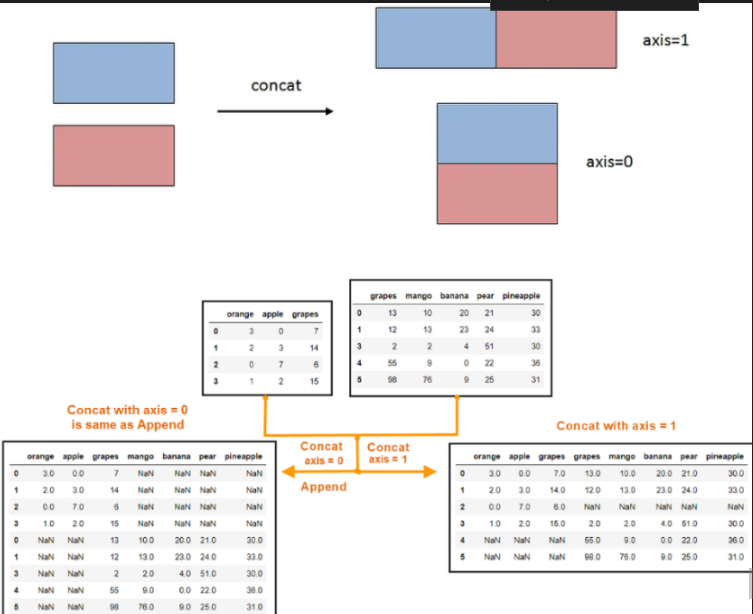

In [134]:
# DataFrame 1: Basic computer specifications
df_computers1 = pd.DataFrame({
    'ComputerID': ['C001', 'C002', 'C003', 'C004'],
    'Brand': ['Dell', 'HP', 'Apple', 'Lenovo'],
    'Model': ['Inspiron', 'Pavilion', 'MacBook', 'ThinkPad'],
    'Processor': ['Intel i5', 'Intel i7', 'M1', 'AMD Ryzen 5'],
    'RAM': ['8GB', '16GB', '8GB', '16GB']
})

In [135]:
df_computers1

,ComputerID,Brand,Model,Processor,RAM
0,C001,Dell,Inspiron,Intel i5,8GB
1,C002,HP,Pavilion,Intel i7,16GB
2,C003,Apple,MacBook,M1,8GB
3,C004,Lenovo,ThinkPad,AMD Ryzen 5,16GB


In [136]:
df_computers2 = pd.DataFrame({
    'ComputerID': ['C006', 'C007', 'C008', 'C009'],
    'Brand': ['Asus', 'Acer', 'Microsoft', 'Samsung'],
    'Model': ['ZenBook', 'Aspire', 'Surface', 'Galaxy Book'],
    'Processor': ['Intel i9', 'AMD Ryzen 7', 'Intel i5', 'Intel i7'],
    'RAM': ['16GB', '8GB', '8GB', '16GB']
})
df_computers2

,ComputerID,Brand,Model,Processor,RAM
0,C006,Asus,ZenBook,Intel i9,16GB
1,C007,Acer,Aspire,AMD Ryzen 7,8GB
2,C008,Microsoft,Surface,Intel i5,8GB
3,C009,Samsung,Galaxy Book,Intel i7,16GB


In [137]:
pd.concat([df_computers1,df_computers2])
# indexes are duplicated right now 

,ComputerID,Brand,Model,Processor,RAM
0,C001,Dell,Inspiron,Intel i5,8GB
1,C002,HP,Pavilion,Intel i7,16GB
2,C003,Apple,MacBook,M1,8GB
3,C004,Lenovo,ThinkPad,AMD Ryzen 5,16GB
0,C006,Asus,ZenBook,Intel i9,16GB
1,C007,Acer,Aspire,AMD Ryzen 7,8GB
2,C008,Microsoft,Surface,Intel i5,8GB
3,C009,Samsung,Galaxy Book,Intel i7,16GB


In [138]:
pd.concat([df_computers1,df_computers2], ignore_index=True)

,ComputerID,Brand,Model,Processor,RAM
0,C001,Dell,Inspiron,Intel i5,8GB
1,C002,HP,Pavilion,Intel i7,16GB
2,C003,Apple,MacBook,M1,8GB
3,C004,Lenovo,ThinkPad,AMD Ryzen 5,16GB
4,C006,Asus,ZenBook,Intel i9,16GB
5,C007,Acer,Aspire,AMD Ryzen 7,8GB
6,C008,Microsoft,Surface,Intel i5,8GB
7,C009,Samsung,Galaxy Book,Intel i7,16GB


In [141]:
pd.concat([df_computers1,df_computers2], axis = 1) # for this table this is not a good concatenation 

,ComputerID,Brand,Model,Processor,RAM,ComputerID,Brand,Model,Processor,RAM
0,C001,Dell,Inspiron,Intel i5,8GB,C006,Asus,ZenBook,Intel i9,16GB
1,C002,HP,Pavilion,Intel i7,16GB,C007,Acer,Aspire,AMD Ryzen 7,8GB
2,C003,Apple,MacBook,M1,8GB,C008,Microsoft,Surface,Intel i5,8GB
3,C004,Lenovo,ThinkPad,AMD Ryzen 5,16GB,C009,Samsung,Galaxy Book,Intel i7,16GB


In [142]:
df_computers3 = pd.DataFrame({
    'ComputerID': ['C001', 'C002', 'C003', 'C005'],
    'Storage': ['256GB SSD', '512GB SSD', '256GB SSD', '1TB HDD'],
    'Graphics': ['Intel UHD', 'NVIDIA GTX 1650', 'Apple GPU', 'AMD Radeon'],
    'Price': [700, 1200, 1500, 800]
})

In [143]:
df_computers3

,ComputerID,Storage,Graphics,Price
0,C001,256GB SSD,Intel UHD,700
1,C002,512GB SSD,NVIDIA GTX 1650,1200
2,C003,256GB SSD,Apple GPU,1500
3,C005,1TB HDD,AMD Radeon,800


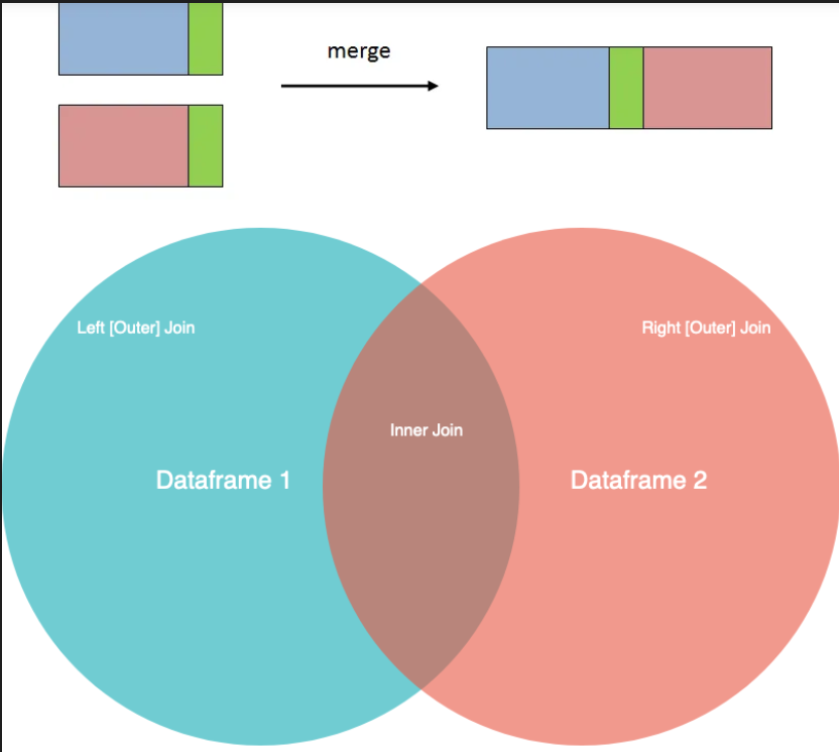

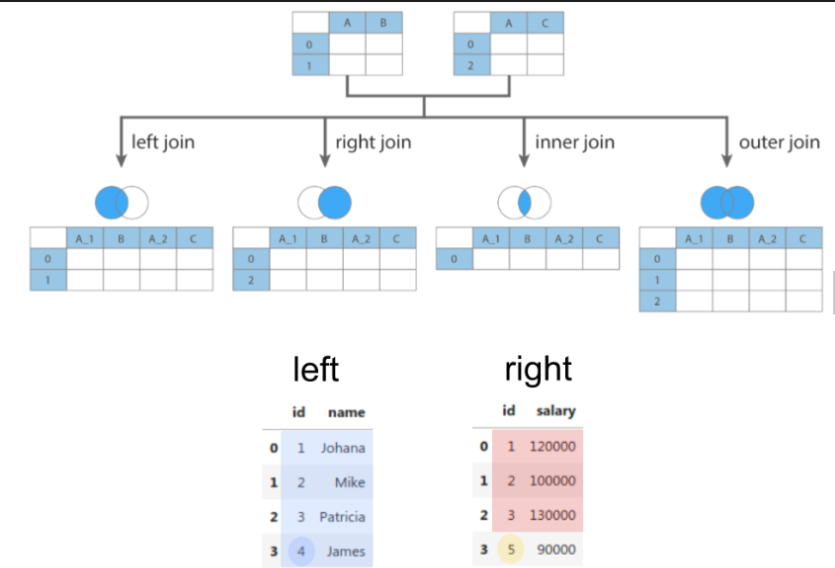

In [144]:
df_computers1

,ComputerID,Brand,Model,Processor,RAM
0,C001,Dell,Inspiron,Intel i5,8GB
1,C002,HP,Pavilion,Intel i7,16GB
2,C003,Apple,MacBook,M1,8GB
3,C004,Lenovo,ThinkPad,AMD Ryzen 5,16GB


In [145]:
df_computers3

,ComputerID,Storage,Graphics,Price
0,C001,256GB SSD,Intel UHD,700
1,C002,512GB SSD,NVIDIA GTX 1650,1200
2,C003,256GB SSD,Apple GPU,1500
3,C005,1TB HDD,AMD Radeon,800


In [146]:
pd.merge(df_computers1,df_computers3)

,ComputerID,Brand,Model,Processor,RAM,Storage,Graphics,Price
0,C001,Dell,Inspiron,Intel i5,8GB,256GB SSD,Intel UHD,700
1,C002,HP,Pavilion,Intel i7,16GB,512GB SSD,NVIDIA GTX 1650,1200
2,C003,Apple,MacBook,M1,8GB,256GB SSD,Apple GPU,1500


In [148]:
pd.merge(df_computers1,df_computers3, on='ComputerID',how='inner')

,ComputerID,Brand,Model,Processor,RAM,Storage,Graphics,Price
0,C001,Dell,Inspiron,Intel i5,8GB,256GB SSD,Intel UHD,700
1,C002,HP,Pavilion,Intel i7,16GB,512GB SSD,NVIDIA GTX 1650,1200
2,C003,Apple,MacBook,M1,8GB,256GB SSD,Apple GPU,1500


In [150]:
df_computers3

,ComputerID,Storage,Graphics,Price
0,C001,256GB SSD,Intel UHD,700
1,C002,512GB SSD,NVIDIA GTX 1650,1200
2,C003,256GB SSD,Apple GPU,1500
3,C005,1TB HDD,AMD Radeon,800


In [149]:
pd.merge(df_computers1,df_computers3, on='ComputerID',how='left')

,ComputerID,Brand,Model,Processor,RAM,Storage,Graphics,Price
0,C001,Dell,Inspiron,Intel i5,8GB,256GB SSD,Intel UHD,700.0
1,C002,HP,Pavilion,Intel i7,16GB,512GB SSD,NVIDIA GTX 1650,1200.0
2,C003,Apple,MacBook,M1,8GB,256GB SSD,Apple GPU,1500.0
3,C004,Lenovo,ThinkPad,AMD Ryzen 5,16GB,NaN,NaN,NaN


In [151]:
pd.merge(df_computers1,df_computers3, on='ComputerID',how='right')

,ComputerID,Brand,Model,Processor,RAM,Storage,Graphics,Price
0,C001,Dell,Inspiron,Intel i5,8GB,256GB SSD,Intel UHD,700
1,C002,HP,Pavilion,Intel i7,16GB,512GB SSD,NVIDIA GTX 1650,1200
2,C003,Apple,MacBook,M1,8GB,256GB SSD,Apple GPU,1500
3,C005,NaN,NaN,NaN,NaN,1TB HDD,AMD Radeon,800


In [152]:
pd.merge(df_computers1,df_computers3, on='ComputerID',how='outer')

,ComputerID,Brand,Model,Processor,RAM,Storage,Graphics,Price
0,C001,Dell,Inspiron,Intel i5,8GB,256GB SSD,Intel UHD,700.0
1,C002,HP,Pavilion,Intel i7,16GB,512GB SSD,NVIDIA GTX 1650,1200.0
2,C003,Apple,MacBook,M1,8GB,256GB SSD,Apple GPU,1500.0
3,C004,Lenovo,ThinkPad,AMD Ryzen 5,16GB,NaN,NaN,NaN
4,C005,NaN,NaN,NaN,NaN,1TB HDD,AMD Radeon,800.0


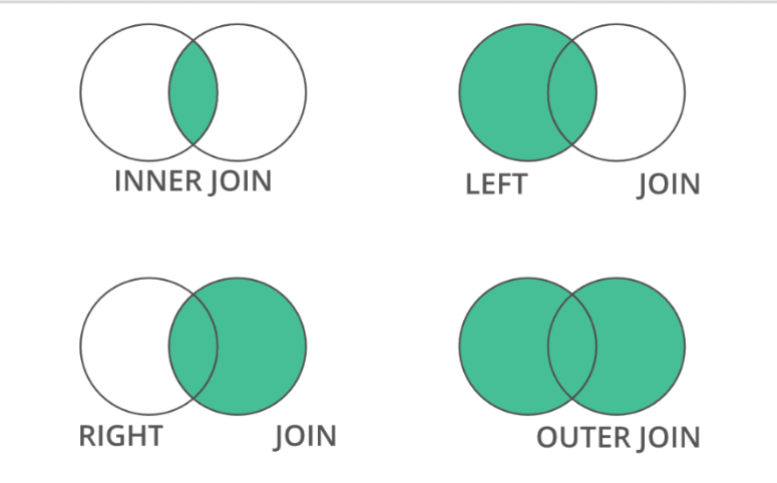

In [153]:
df_employees = pd.DataFrame({
    'EmployeeID': ['E001', 'E002', 'E003', 'E004'],
    'Name': ['Alice', 'Bob', 'Charlie', 'David'],
    'Department': ['HR', 'Engineering', 'Marketing', 'Finance']
})

In [154]:
df_employees

,EmployeeID,Name,Department
0,E001,Alice,HR
1,E002,Bob,Engineering
2,E003,Charlie,Marketing
3,E004,David,Finance


In [156]:
df_salaries = pd.DataFrame({
    'EmployeeID': ['E001', 'E002', 'E005', 'E006'],
    'Salary': [50000, 60000, 70000, 80000]
})

In [157]:
df_salaries

,EmployeeID,Salary
0,E001,50000
1,E002,60000
2,E005,70000
3,E006,80000


In [159]:
df_employees.join(df_salaries) # ERROR 

ValueError: columns overlap but no suffix specified: Index(['EmployeeID'], dtype='object')

In [160]:
df_employees.set_index('EmployeeID').join(df_salaries.set_index('EmployeeID'), how='inner')

,Name,Department,Salary
EmployeeID,,,
E001,Alice,HR,50000
E002,Bob,Engineering,60000


In [162]:
df_employees.set_index('EmployeeID', inplace=True)

In [163]:
df_employees

,Name,Department
EmployeeID,,
E001,Alice,HR
E002,Bob,Engineering
E003,Charlie,Marketing
E004,David,Finance


In [165]:
df_salaries.set_index('EmployeeID', inplace=True)

In [166]:
df_salaries

,Salary
EmployeeID,
E001,50000
E002,60000
E005,70000
E006,80000


In [167]:
df_employees.join(df_salaries,how='inner')

,Name,Department,Salary
EmployeeID,,,
E001,Alice,HR,50000
E002,Bob,Engineering,60000


In [168]:
df_employees.join(df_salaries,how='outer')

,Name,Department,Salary
EmployeeID,,,
E001,Alice,HR,50000.0
E002,Bob,Engineering,60000.0
E003,Charlie,Marketing,NaN
E004,David,Finance,NaN
E005,NaN,NaN,70000.0
E006,NaN,NaN,80000.0
